# **Hybrid Recommendation System**

Proyek IDCamp Developer Challenge - Sistem Rekomendasi Produk Software (Deep Learning based, NeuMF Hybrid)

Dataset: Amazon US Customer Reviews, subset kategori Software
File: amazon_reviews_us_Software_v1_00.csv

Notebook ini mencakup dua tahap awal pipeline:
1. Data Loading (baca data secara efisien dari Google Drive)
2. Exploratory Data Analysis (memahami distribusi rating, sparsity, dan pola long tail)

Catatan penting: dataset asli didistribusikan dalam format TSV (tab separated). Jika file sudah dikonversi manual ke CSV, pastikan tidak ada isi kolom teks (review_body atau review_headline) yang mengandung koma tanpa tanda kutip, karena hal ini bisa menggeser kolom saat parsing. Jika hasil pembacaan data terlihat aneh (jumlah kolom tidak sesuai), sebaiknya kembali memakai file TSV asli dengan sep="\t".


## **LOAD DATA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')

# Seed untuk reproducibility, dipakai konsisten di seluruh pipeline
SEED = 42
np.random.seed(SEED)

print('Setup selesai.')

Setup selesai.


In [ ]:
DATA_PATH = "/content/drive/MyDrive/ROAD TO GEMASTIK XIX/LOMBA/IDCAMP Challenge/amazon_reviews_us_Software_v1_00.tsv"

print(f'Path dataset : {DATA_PATH}')
print(f'File ditemukan : {os.path.exists(DATA_PATH)}')

df = pd.read_csv(DATA_PATH,  sep='\t', engine='python', on_bad_lines='skip')

print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
df.head()

Path dataset : /content/drive/MyDrive/ROAD TO GEMASTIK XIX/LOMBA/IDCAMP Challenge/amazon_reviews_us_Software_v1_00.tsv
File ditemukan : True
Jumlah baris  : 340,844
Jumlah kolom  : 15


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,42605767,R3EFW2STIYIY0I,B00MUTIDKI,248732228,McAfee 2015 Internet Security 3 PC (3-Users),Software,1,2,2,N,Y,I was very disappointed with this,I was very disappointed with this. The descrip...,2015-08-31
1,US,51771800,R12NR0R5A9F7FT,B00EPACNUG,531462352,Hallmark Card Studio 2014,Software,5,0,0,N,Y,Five Stars,"I had a little struggle getting familiarized, ...",2015-08-31
2,US,16053526,R1LSH74R9XAP59,B00164AZA4,473982505,Search and Rescue 4,Software,2,0,1,N,Y,Have windows 10?,Tried to download it on my Windows 10 and it w...,2015-08-31
3,US,15319481,R1QXUNTF76K7L6,B00E6LIEFM,189774198,Quickbooks Pro,Software,2,0,0,N,Y,"Disc was corrupt, had to spend a couple hours ...","Disc was corrupt, had to spend a couple hours ...",2015-08-31
4,US,1441820,R2F7DR75PS8NKT,B00VWEBG06,852470365,Windows 7 Professional with Service Pack 1 (64...,Software,5,0,0,N,Y,Five Stars,Just what I needed. Took a little longer to sh...,2015-08-31


In [ ]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340844 entries, 0 to 340843
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   marketplace        340844 non-null  object
 1   customer_id        340844 non-null  int64 
 2   review_id          340844 non-null  object
 3   product_id         340844 non-null  object
 4   product_parent     340844 non-null  int64 
 5   product_title      340834 non-null  object
 6   product_category   340844 non-null  object
 7   star_rating        340844 non-null  int64 
 8   helpful_votes      340844 non-null  int64 
 9   total_votes        340844 non-null  int64 
 10  vine               340844 non-null  object
 11  verified_purchase  340844 non-null  object
 12  review_headline    340837 non-null  object
 13  review_body        340835 non-null  object
 14  review_date        340844 non-null  object
dtypes: int64(5), object(10)
memory usage: 400.9 MB


## **Exploratory Data Analyst**

### **Pemeriksaan Kualitas Data**

In [ ]:
missing_count = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'missing_count': missing_count,
    'missing_pct': missing_pct,
})

missing_report[missing_report['missing_count'] > 0]

,missing_count,missing_pct
product_title,10,0.0
review_body,9,0.0
review_headline,7,0.0


In [ ]:
duplicate_review_ids = df.duplicated(subset=['review_id']).sum()
duplicate_full_rows = df.duplicated().sum()

print(f'review_id duplikat : {duplicate_review_ids:,}')
print(f'baris duplikat total : {duplicate_full_rows:,}')

review_id duplikat : 0
baris duplikat total : 0


### **Distribusi Rating**

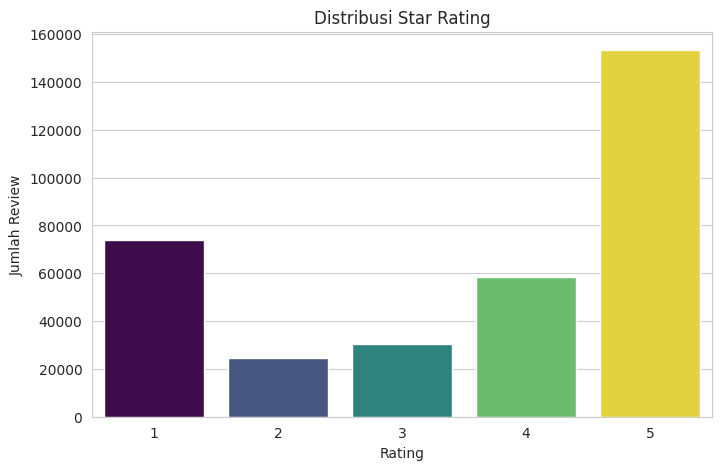

Proporsi tiap rating (persen):
star_rating
1    21.65
2     7.21
3     8.98
4    17.17
5    44.99
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='star_rating', hue='star_rating', palette='viridis', legend=False)
plt.title('Distribusi Star Rating')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')
plt.show()

rating_share = df['star_rating'].value_counts(normalize=True).sort_index() * 100
print('Proporsi tiap rating (persen):')
print(rating_share.round(2))

### **Analisis Vine dan Verified Purchase**

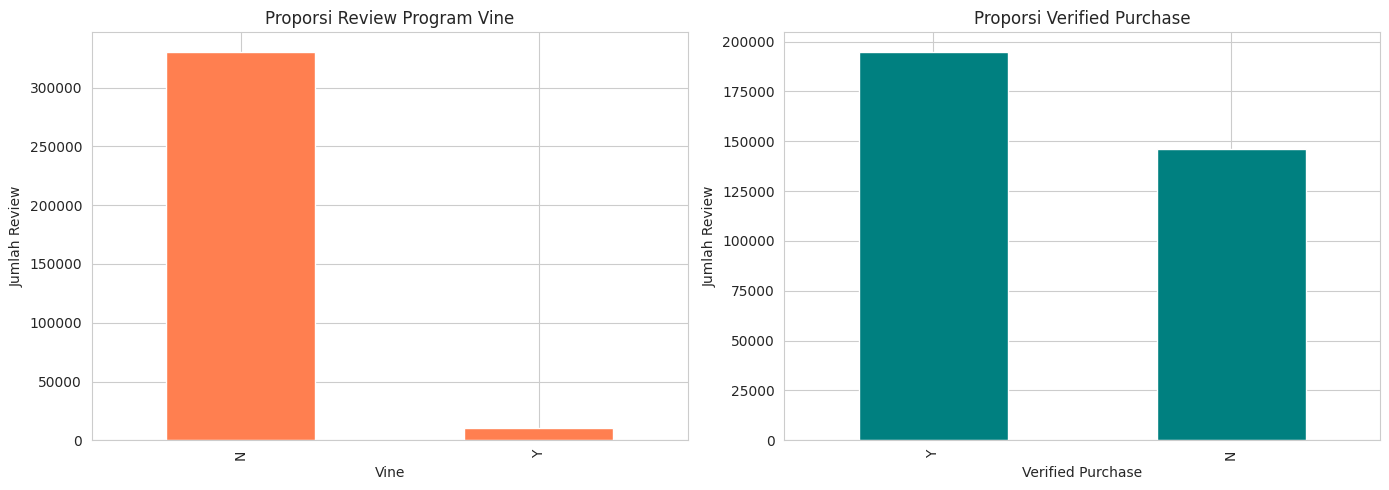

vine
N    3.557872
Y    3.839342
Name: star_rating, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['vine'].value_counts().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Proporsi Review Program Vine')
axes[0].set_xlabel('Vine')
axes[0].set_ylabel('Jumlah Review')

df['verified_purchase'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Proporsi Verified Purchase')
axes[1].set_xlabel('Verified Purchase')
axes[1].set_ylabel('Jumlah Review')

plt.tight_layout()
plt.show()

print(df.groupby('vine', observed=True)['star_rating'].mean())

### **Sparsity Matrix User-Item**

In [ ]:
n_users = df['customer_id'].nunique()
n_items = df['product_parent'].nunique()
n_interactions = len(df)

sparsity = 1 - (n_interactions / (n_users * n_items))

print(f'Jumlah user unik   : {n_users:,}')
print(f'Jumlah produk unik : {n_items:,}')
print(f'Jumlah interaksi   : {n_interactions:,}')
print(f'Sparsity matrix    : {sparsity * 100:.4f} persen')

Jumlah user unik   : 274,552
Jumlah produk unik : 28,163
Jumlah interaksi   : 340,844
Sparsity matrix    : 99.9956 persen


### **Distribusi Long Tail (Aktivitas User dan Popularitas Produk)**

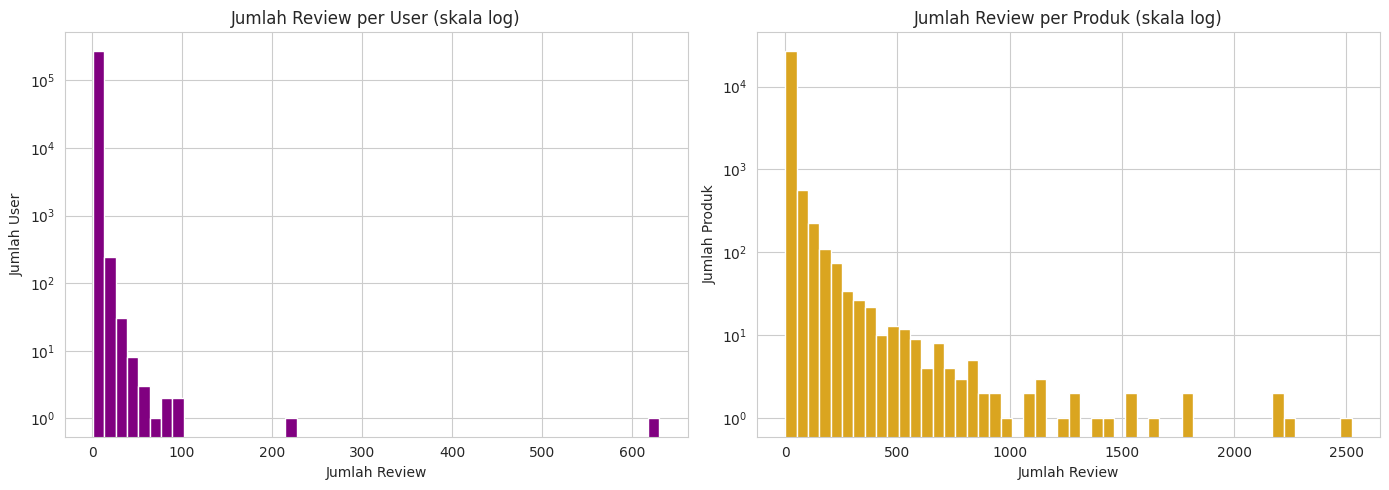

Median review per user   : 1.0
Median review per produk : 2.0
User dengan tepat 1 review   : 87.20 persen
Produk dengan tepat 1 review : 41.75 persen


In [ ]:
user_activity = df['customer_id'].value_counts()
item_popularity = df['product_parent'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_activity, bins=50, color='purple', log=True)
axes[0].set_title('Jumlah Review per User (skala log)')
axes[0].set_xlabel('Jumlah Review')
axes[0].set_ylabel('Jumlah User')

axes[1].hist(item_popularity, bins=50, color='goldenrod', log=True)
axes[1].set_title('Jumlah Review per Produk (skala log)')
axes[1].set_xlabel('Jumlah Review')
axes[1].set_ylabel('Jumlah Produk')

plt.tight_layout()
plt.show()

print(f'Median review per user   : {user_activity.median()}')
print(f'Median review per produk : {item_popularity.median()}')
print(f'User dengan tepat 1 review   : {(user_activity == 1).mean() * 100:.2f} persen')
print(f'Produk dengan tepat 1 review : {(item_popularity == 1).mean() * 100:.2f} persen')

### **Rentang Waktu Data**

Review paling awal  : 1998-09-21 00:00:00
Review paling akhir : 2015-08-31 00:00:00


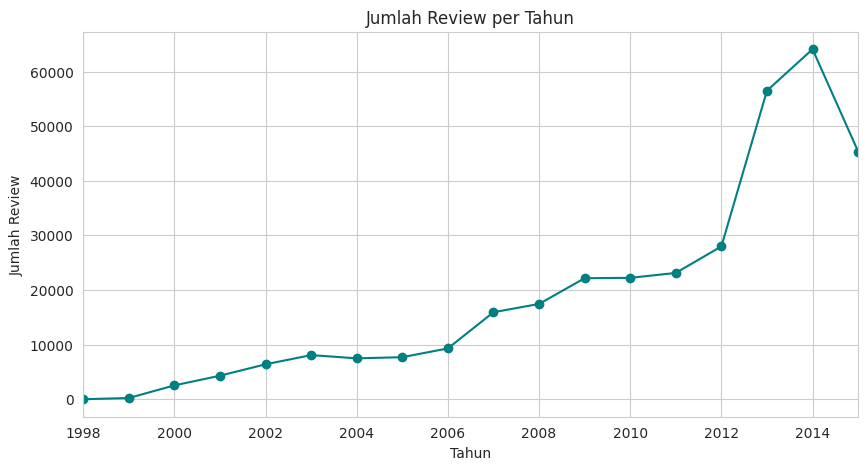

In [ ]:
# Konversi review_date ke datetime agar bisa di-resample
df['review_date'] = pd.to_datetime(df['review_date'])

print(f'Review paling awal  : {df["review_date"].min()}')
print(f'Review paling akhir : {df["review_date"].max()}')

df.set_index('review_date').resample('YE').size().plot(figsize=(10, 5), marker='o', color='teal')
plt.title('Jumlah Review per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Review')
plt.show()

### **Analisis Singkat Panjang Teks**

In [ ]:
df['review_length'] = df['review_body'].str.len()
df['title_length'] = df['product_title'].str.len()

df[['review_length', 'title_length']].describe()

,review_length,title_length
count,340835.00000,340834.000000
mean,581.01298,42.043417
std,999.86905,23.561810
min,1.00000,1.000000
25%,138.00000,27.000000
50%,299.00000,39.000000
75%,664.00000,52.000000
max,48379.00000,400.000000


## **Cleaning & Filtering Data**

In [ ]:
before = len(df)

df = df.dropna(subset=['product_title', 'review_body', 'review_headline']).reset_index(drop=True)

after = len(df)

print(f'Baris sebelum : {before:,}')
print(f'Baris sesudah : {after:,}')
print(f'Baris dibuang : {before - after}')

Baris sebelum : 340,844
Baris sesudah : 340,818
Baris dibuang : 26


## **Feature Engineering**

### **Penanganan Vine**

In [ ]:
df['is_vine'] = (df['vine'] == 'Y').astype(int)

print(df['is_vine'].value_counts())
print(f'Proporsi Vine: {df["is_vine"].mean() * 100:.3f} persen')

is_vine
0    330417
1     10401
Name: count, dtype: int64
Proporsi Vine: 3.052 persen


### **Iterative K-core Filtering**

In [ ]:
def k_core_filter(data, user_col, item_col, k):
    data = data.copy()

    while True:
        user_counts = data[user_col].value_counts()
        item_counts = data[item_col].value_counts()

        valid_users = user_counts[user_counts >= k].index
        valid_items = item_counts[item_counts >= k].index

        filtered = data[data[user_col].isin(valid_users) & data[item_col].isin(valid_items)]

        if len(filtered) == len(data):
            break

        data = filtered

    return data.reset_index(drop=True)

In [ ]:
for k in [2, 3, 5, 10]:
    result = k_core_filter(df, 'customer_id', 'product_parent', k)
    pct_retained = len(result) / len(df) * 100
    n_users = result['customer_id'].nunique()
    n_items = result['product_parent'].nunique()

    print(f'k = {k:>2} | baris tersisa: {len(result):>8,} ({pct_retained:5.2f} persen) '
          f'| user: {n_users:>7,} | produk: {n_items:>6,}')

k =  2 | baris tersisa:   89,887 (26.37 persen) | user:  31,702 | produk:  7,678
k =  3 | baris tersisa:   37,760 (11.08 persen) | user:   8,350 | produk:  2,907
k =  5 | baris tersisa:    9,794 ( 2.87 persen) | user:   1,221 | produk:    650
k = 10 | baris tersisa:       10 ( 0.00 persen) | user:       1 | produk:      1


In [ ]:
CORE_THRESHOLD = 2  # sesuaikan berdasarkan hasil cell di atas

df_clean = k_core_filter(df, 'customer_id', 'product_parent', CORE_THRESHOLD)

print(f'Threshold k-core        : {CORE_THRESHOLD}')
print(f'Baris setelah filtering : {len(df_clean):,}')
print(f'User tersisa            : {df_clean["customer_id"].nunique():,}')
print(f'Produk tersisa          : {df_clean["product_parent"].nunique():,}')

Threshold k-core        : 2
Baris setelah filtering : 89,887
User tersisa            : 31,702
Produk tersisa          : 7,678


### **Pelabelan Implicit Feedback**

In [ ]:
df_clean['label_implicit'] = (df_clean['star_rating'] >= 4).astype(int)

print((df_clean['label_implicit'].value_counts(normalize=True) * 100).round(2))

label_implicit
1    64.22
0    35.78
Name: proportion, dtype: float64


### **Temporal Train-Test Split**

In [ ]:
split_date = df_clean['review_date'].quantile(0.8)

train_df = df_clean[df_clean['review_date'] <= split_date].copy()
test_df = df_clean[df_clean['review_date'] > split_date].copy()

print(f'Titik potong split : {split_date}')
print(f'Baris train        : {len(train_df):,}')
print(f'Baris test         : {len(test_df):,}')

Titik potong split : 2014-08-01 00:00:00
Baris train        : 71,927
Baris test         : 17,960


### **Buang User/Produk Cold-start dari Test Set**

In [ ]:
known_users = train_df['customer_id'].unique()
known_items = train_df['product_parent'].unique()

before_test = len(test_df)

test_df = test_df[
    test_df['customer_id'].isin(known_users) & test_df['product_parent'].isin(known_items)
].reset_index(drop=True)

after_test = len(test_df)

print(f'Baris test sebelum filter  : {before_test:,}')
print(f'Baris test sesudah filter  : {after_test:,}')
print(f'Baris dibuang (cold-start) : {before_test - after_test:,}')

Baris test sebelum filter  : 17,960
Baris test sesudah filter  : 4,489
Baris dibuang (cold-start) : 13,471


### **Label Encoding User dan Produk**

In [ ]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

train_df['user_idx'] = user_encoder.fit_transform(train_df['customer_id'])
train_df['item_idx'] = item_encoder.fit_transform(train_df['product_parent'])

test_df['user_idx'] = user_encoder.transform(test_df['customer_id'])
test_df['item_idx'] = item_encoder.transform(test_df['product_parent'])

n_users = len(user_encoder.classes_)
n_items = len(item_encoder.classes_)

print(f'Jumlah user unik (dimensi embedding user)   : {n_users:,}')
print(f'Jumlah produk unik (dimensi embedding item) : {n_items:,}')

Jumlah user unik (dimensi embedding user)   : 27,625
Jumlah produk unik (dimensi embedding item) : 7,202


### **Tabel Metadata Produk**

In [ ]:
item_metadata = (
    df_clean[['product_parent', 'product_title', 'product_category']]
    .drop_duplicates(subset='product_parent')
    .set_index('product_parent')
)

item_metadata = item_metadata.loc[item_encoder.classes_]
item_metadata['item_idx'] = item_encoder.transform(item_metadata.index)
item_metadata = item_metadata.sort_values('item_idx').reset_index()

item_metadata.head()

,product_parent,product_title,product_category,item_idx
0,55782,"Rosetta Stone V2: Latin, Level 1",Software,0
1,119183,Workstation V6 Win CD [OLD VERSION],Software,1
2,121474,QuickBooks Online Simple Start 2013,Software,2
3,170101,Cakewalk Pyro 5,Software,3
4,333919,Acronis True Image 6.0,Software,4


### **Content Embedding dari Judul Produk (TF-IDF)**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=300, stop_words='english')
item_content_matrix = tfidf.fit_transform(item_metadata['product_title'].fillna(''))

print(f'Dimensi content embedding: {item_content_matrix.shape}')

Dimensi content embedding: (7202, 300)


### **Negative Sampling**

In [ ]:
def generate_negative_samples(interactions_df, n_items, n_negatives=4, seed=SEED):
    rng = np.random.default_rng(seed)

    user_positive_items = interactions_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    neg_users = []
    neg_items = []

    for user_idx, positive_items in user_positive_items.items():
        n_needed = len(positive_items) * n_negatives
        sampled = set()

        while len(sampled) < n_needed:
            candidate = int(rng.integers(0, n_items))
            if candidate not in positive_items:
                sampled.add(candidate)

        neg_users.extend([user_idx] * len(sampled))
        neg_items.extend(list(sampled))

    return pd.DataFrame({
        'user_idx': neg_users,
        'item_idx': neg_items,
        'label_implicit': 0,
    })

In [ ]:
train_negatives = generate_negative_samples(train_df, n_items, n_negatives=4)

print(f'Jumlah sampel positif : {len(train_df):,}')
print(f'Jumlah sampel negatif : {len(train_negatives):,}')

train_positive = train_df[['user_idx', 'item_idx', 'label_implicit']].copy()
train_final = pd.concat([train_positive, train_negatives], ignore_index=True)
train_final = train_final.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Total baris data training (positif + negatif): {len(train_final):,}')
train_final['label_implicit'].value_counts()

Jumlah sampel positif : 71,927
Jumlah sampel negatif : 284,292
Total baris data training (positif + negatif): 356,219


,count
label_implicit,
0,311512
1,44707


### **Simpan Semua Artefak**

In [ ]:
import pickle
import scipy.sparse as sp
import os

# Definisikan folder untuk menyimpan artefak
ARTIFACT_FOLDER = 'artifacts'
os.makedirs(ARTIFACT_FOLDER, exist_ok=True)

train_final.to_parquet(os.path.join(ARTIFACT_FOLDER, 'train_final.parquet'), index=False)

test_df[['user_idx', 'item_idx', 'label_implicit', 'star_rating']].to_parquet(
    os.path.join(ARTIFACT_FOLDER, 'test_final.parquet'), index=False
)

item_metadata.to_parquet(os.path.join(ARTIFACT_FOLDER, 'item_metadata.parquet'), index=False)

sp.save_npz(os.path.join(ARTIFACT_FOLDER, 'item_content_matrix.npz'), item_content_matrix)

with open(os.path.join(ARTIFACT_FOLDER, 'user_encoder.pkl'), 'wb') as f:
    pickle.dump(user_encoder, f)

with open(os.path.join(ARTIFACT_FOLDER, 'item_encoder.pkl'), 'wb') as f:
    pickle.dump(item_encoder, f)

with open(os.path.join(ARTIFACT_FOLDER, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)

print('Semua artefak berhasil disimpan ke:')
print(os.path.abspath(ARTIFACT_FOLDER))

Semua artefak berhasil disimpan ke:
/content/artifacts


## **Baseline Model: Popularity-based Recommender**

### **Fungsi Metrik Evaluasi**

In [ ]:
def precision_at_k(recommended, actual, k):
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(actual))
    return hits / k


def recall_at_k(recommended, actual, k):
    if len(actual) == 0:
        return 0.0
    recommended_k = recommended[:k]
    hits = len(set(recommended_k) & set(actual))
    return hits / len(actual)


def ndcg_at_k(recommended, actual, k):
    recommended_k = recommended[:k]
    dcg = 0.0
    for i, item in enumerate(recommended_k):
        if item in actual:
            dcg += 1 / np.log2(i + 2)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), k)))
    return dcg / idcg if idcg > 0 else 0.0


def hit_rate_at_k(recommended, actual, k):
    recommended_k = recommended[:k]
    return 1.0 if len(set(recommended_k) & set(actual)) > 0 else 0.0

### **Fungsi Evaluasi Umum**

In [ ]:
def evaluate_recommender(get_recommendations_fn, test_df, k=10):
    test_user_items = test_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    precisions, recalls, ndcgs, hit_rates = [], [], [], []

    for user_idx, actual_items in test_user_items.items():
        recommended_items = get_recommendations_fn(user_idx, k)

        precisions.append(precision_at_k(recommended_items, actual_items, k))
        recalls.append(recall_at_k(recommended_items, actual_items, k))
        ndcgs.append(ndcg_at_k(recommended_items, actual_items, k))
        hit_rates.append(hit_rate_at_k(recommended_items, actual_items, k))

    return {
        'Precision@K': np.mean(precisions),
        'Recall@K': np.mean(recalls),
        'NDCG@K': np.mean(ndcgs),
        'HitRate@K': np.mean(hit_rates),
    }

### **Bangun Ranking Popularitas dari Train**

In [ ]:
item_popularity_rank = train_df['item_idx'].value_counts().index.tolist()

print(f'Jumlah produk dalam ranking popularitas: {len(item_popularity_rank):,}')
print(f'Top 5 produk terpopuler (item_idx): {item_popularity_rank[:5]}')

Jumlah produk dalam ranking popularitas: 7,202
Top 5 produk terpopuler (item_idx): [5146, 5051, 2663, 1344, 4596]


### **Fungsi Rekomendasi Popularitas**

In [ ]:
user_train_items = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()


def get_popularity_recommendations(user_idx, k):
    seen_items = user_train_items.get(user_idx, set())
    recommendations = []

    for item_idx in item_popularity_rank:
        if item_idx not in seen_items:
            recommendations.append(item_idx)
        if len(recommendations) == k:
            break

    return recommendations

### **Evaluasi Baseline**

In [ ]:
K = 10

model_results = {}
model_results['Popularity Baseline'] = evaluate_recommender(get_popularity_recommendations, test_df, k=K)

pd.DataFrame(model_results).T.round(4)

,Precision@K,Recall@K,NDCG@K,HitRate@K
Popularity Baseline,0.0058,0.044,0.0204,0.0563


## **Model Utama: NeuMF Hybrid**|

### **Persiapan Content Matrix**

In [ ]:
import torch

item_content_dense = item_content_matrix.toarray().astype(np.float32)
item_content_tensor = torch.tensor(item_content_dense, dtype=torch.float32)

print(f'Dimensi content matrix dense: {item_content_dense.shape}')

Dimensi content matrix dense: (7202, 300)


### **Dataset Class**

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class InteractionDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_idx'].values, dtype=torch.long)
        self.items = torch.tensor(df['item_idx'].values, dtype=torch.long)
        self.labels = torch.tensor(df['label_implicit'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.labels[idx]

### **DataLoader**

In [ ]:
BATCH_SIZE = 512

train_dataset = InteractionDataset(train_final)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'Jumlah baris training : {len(train_dataset):,}')
print(f'Jumlah batch per epoch : {len(train_loader):,}')

Jumlah baris training : 356,219
Jumlah batch per epoch : 696


### **Arsitektur NeuMF Hybrid**

In [ ]:
class NeuMFHybrid(nn.Module):
    def __init__(self, n_users, n_items, content_dim, item_content_matrix,
                 gmf_dim=32, mlp_dim=32, mlp_hidden=[128, 64, 32], content_proj_dim=32):
        super().__init__()

        # Cabang GMF
        self.user_emb_gmf = nn.Embedding(n_users, gmf_dim)
        self.item_emb_gmf = nn.Embedding(n_items, gmf_dim)

        # Cabang MLP
        self.user_emb_mlp = nn.Embedding(n_users, mlp_dim)
        self.item_emb_mlp = nn.Embedding(n_items, mlp_dim)

        mlp_layers = []
        input_dim = mlp_dim * 2
        for hidden_dim in mlp_hidden:
            mlp_layers.append(nn.Linear(input_dim, hidden_dim))
            mlp_layers.append(nn.ReLU())
            mlp_layers.append(nn.Dropout(0.2))
            input_dim = hidden_dim
        self.mlp = nn.Sequential(*mlp_layers)

        # Cabang content
        self.content_proj = nn.Sequential(
            nn.Linear(content_dim, content_proj_dim),
            nn.ReLU(),
        )

        # Content matrix disimpan sebagai buffer, bukan parameter yang dilatih
        self.register_buffer('item_content_matrix', item_content_matrix)

        # Fusion layer
        fusion_input_dim = gmf_dim + mlp_hidden[-1] + content_proj_dim
        self.fusion = nn.Sequential(
            nn.Linear(fusion_input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )

    def forward(self, user_idx, item_idx):
        gmf_out = self.user_emb_gmf(user_idx) * self.item_emb_gmf(item_idx)

        mlp_input = torch.cat([self.user_emb_mlp(user_idx), self.item_emb_mlp(item_idx)], dim=1)
        mlp_out = self.mlp(mlp_input)

        content_vec = self.item_content_matrix[item_idx]
        content_out = self.content_proj(content_vec)

        fused = torch.cat([gmf_out, mlp_out, content_out], dim=1)
        score = self.fusion(fused)

        return score.squeeze(1)

### **Inisialisasi Model**

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = NeuMFHybrid(
    n_users=n_users,
    n_items=n_items,
    content_dim=item_content_tensor.shape[1],
    item_content_matrix=item_content_tensor,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'Device        : {device}')
print(f'Total parameter yang dilatih : {n_params:,}')
print()
print(model)

Device        : cuda
Total parameter yang dilatih : 2,263,489

NeuMFHybrid(
  (user_emb_gmf): Embedding(27625, 32)
  (item_emb_gmf): Embedding(7202, 32)
  (user_emb_mlp): Embedding(27625, 32)
  (item_emb_mlp): Embedding(7202, 32)
  (mlp): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
  )
  (content_proj): Sequential(
    (0): Linear(in_features=300, out_features=32, bias=True)
    (1): ReLU()
  )
  (fusion): Sequential(
    (0): Linear(in_features=96, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)


## **Training NeuMF Hybrid**

### **Split Validation dari Train**

In [ ]:
from sklearn.model_selection import train_test_split

train_split_df, val_split_df = train_test_split(
    train_final, test_size=0.1, random_state=SEED, stratify=train_final['label_implicit']
)

print(f'Baris train (update bobot)      : {len(train_split_df):,}')
print(f'Baris validation (early stopping): {len(val_split_df):,}')

Baris train (update bobot)      : 320,597
Baris validation (early stopping): 35,622


### **DataLoader Train dan Validation**

In [ ]:
train_split_dataset = InteractionDataset(train_split_df)
val_split_dataset = InteractionDataset(val_split_df)

train_split_loader = DataLoader(train_split_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_split_loader = DataLoader(val_split_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch per epoch (train) : {len(train_split_loader):,}')
print(f'Batch per epoch (val)   : {len(val_split_loader):,}')

Batch per epoch (train) : 627
Batch per epoch (val)   : 70


### **Loss Function dan Optimizer**

In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print('Loss function : BCEWithLogitsLoss')
print('Optimizer     : Adam, learning rate 0.001')

Loss function : BCEWithLogitsLoss
Optimizer     : Adam, learning rate 0.001


### **Fungsi Satu Epoch Training dan Evaluasi**

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for users, items, labels in loader:
        users, items, labels = users.to(device), items.to(device), labels.to(device)

        optimizer.zero_grad()
        scores = model(users, items)
        loss = criterion(scores, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(users)

    return total_loss / len(loader.dataset)


def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for users, items, labels in loader:
            users, items, labels = users.to(device), items.to(device), labels.to(device)
            scores = model(users, items)
            loss = criterion(scores, labels)
            total_loss += loss.item() * len(users)

    return total_loss / len(loader.dataset)

### **Training Loop dengan Early Stopping**

In [ ]:
N_EPOCHS = 30
PATIENCE = 5

best_val_loss = float('inf')
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': []}

BEST_MODEL_PATH = os.path.join(ARTIFACT_FOLDER, 'neumf_hybrid_best.pt')

for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_split_loader, criterion, optimizer, device)
    val_loss = evaluate_loss(model, val_split_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f'Epoch {epoch:>3} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f'Early stopping di epoch {epoch}, val_loss tidak membaik selama {PATIENCE} epoch.')
        break

print(f'Model terbaik disimpan di: {BEST_MODEL_PATH}')

Epoch   1 | train_loss: 0.3575 | val_loss: 0.3350
Epoch   2 | train_loss: 0.3256 | val_loss: 0.3195
Epoch   3 | train_loss: 0.3085 | val_loss: 0.3164
Epoch   4 | train_loss: 0.2956 | val_loss: 0.3196
Epoch   5 | train_loss: 0.2827 | val_loss: 0.3252
Epoch   6 | train_loss: 0.2669 | val_loss: 0.3429
Epoch   7 | train_loss: 0.2495 | val_loss: 0.3558
Epoch   8 | train_loss: 0.2292 | val_loss: 0.3813
Early stopping di epoch 8, val_loss tidak membaik selama 5 epoch.
Model terbaik disimpan di: artifacts/neumf_hybrid_best.pt


### **Kurva Training**

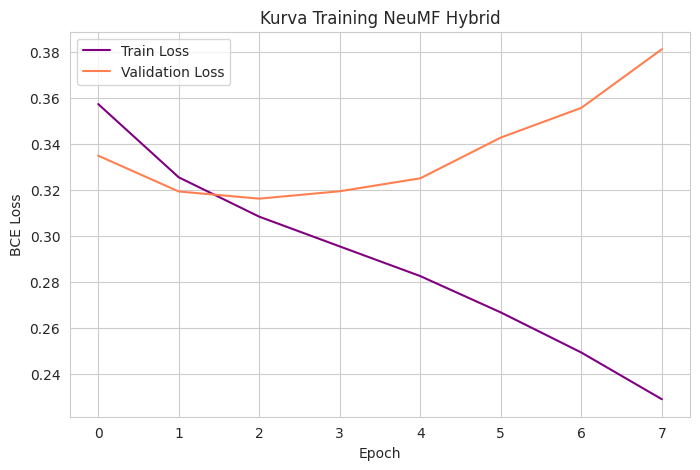

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='Train Loss', color='purple')
plt.plot(history['val_loss'], label='Validation Loss', color='coral')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.title('Kurva Training NeuMF Hybrid')
plt.legend()
plt.show()

### **Muat Ulang Model Terbaik**

In [ ]:
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

print('Model terbaik berhasil dimuat kembali.')

Model terbaik berhasil dimuat kembali.
